# Broadband Extended Ptychographic Iterative Engine (ePIE)

A basic python implementation of the seminal paper by Rodenburg *et al*:
1. **Rodenburg, J. M., & Faulkner, H. M. L.** (2004). *A phase retrieval algorithm for shifting illumination*. *Applied Physics Letters, 85*(20), 4795–4797. [https://doi.org/10.1063/1.1823034](https://doi.org/10.1063/1.1823034)
1. **Maiden, A. M., & Rodenburg, J. M.** (2009). *An improved ptychographical phase retrieval algorithm for diffractive imaging*. *Ultramicroscopy, 109*(10), 1256–1262. [https://doi.org/10.1016/j.ultramic.2009.05.012](https://doi.org/10.1016/j.ultramic.2009.05.012)


Dataset taken from:

1. **Maiden, Andrew.** (2024). *Example ptychography datasets from the University of Sheffield*. *The University of Sheffield*. Dataset. [https://doi.org/10.15131/shef.data.24893688.v1](https://doi.org/10.15131/shef.data.24893688.v1)


In [1]:
from IPython.display import display, clear_output
from utils import *
from pathlib import Path
from pprint import PrettyPrinter
from matplotlib import pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, map_coordinates

printer = PrettyPrinter(indent=4, width=60, depth=2, compact=False)
pprint = printer.pprint

f2s = freq2space2
s2f = space2freq2

## Spectrum

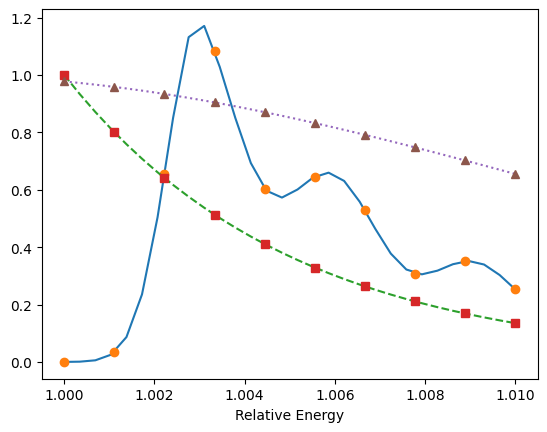

In [2]:
# "Continuous" spectrum
Nl = 30
en = np.linspace(1, 1.01, Nl)

# Sampled spectrum
Nls = 10
en_s = np.linspace(en[0], en[-1], Nls)
ls = 1 / en_s

en0 = 1.003
l0 = 1 / en0

spe1 = lambda en: np.exp(
    -(((en <= en0) * (en - en0) / 0.001) ** 2)
    - ((en > en0) * (en - en0) / 0.005)
) * (1 + 0.2 * np.cos((en > en0) * (en - en0) * 2e3))
spe2 = lambda en: np.exp(-(en-en[0])/.005)
spe3 = lambda en: np.exp(-((en-2*en[0]+en0)/.02)**2)


plt.plot(en, spe1(en))
plt.plot(en_s, spe1(en_s), "o")

plt.plot(en, spe2(en), "--")
plt.plot(en_s, spe2(en_s), "s")

plt.plot(en, spe3(en), ":")
plt.plot(en_s, spe3(en_s), "^")

plt.xlabel("Relative Energy")
plt.show()

## Load data

In [3]:
resource_path = Path.cwd().joinpath("resources")
load_neuron = False


Loads a neuron image and extract the RGBL (red, green, blue, luminosity) values

In [4]:
if load_neuron:
    overlap = 0.75
    
    filename = resource_path.joinpath("neuron.jpg")
    img = Image.open(filename)
    L = np.array(img.convert("L"))
    R, G, B = map(np.array, img.split())
    indx = (350, 800)
    indy = (250, 550)
    L = L[indy[0]:indy[1], indx[0]:indx[1]]
    R = R[indy[0]:indy[1], indx[0]:indx[1]]
    G = G[indy[0]:indy[1], indx[0]:indx[1]]
    B = B[indy[0]:indy[1], indx[0]:indx[1]]

    sample = sqrt(L / L.max()) * np.exp(1j * TAU * (B / B.max()))

    # Display images
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
    axs = axs.flatten()

    ax = axs[0]
    ax.imshow(R)
    ax.set_title("R")

    ax = axs[1]
    ax.imshow(G)
    ax.set_title("G")

    ax = axs[2]
    ax.imshow(B)
    ax.set_title("B")

    ax = axs[3]
    ax.imshow(L)
    ax.set_title("L")

    plt.show()

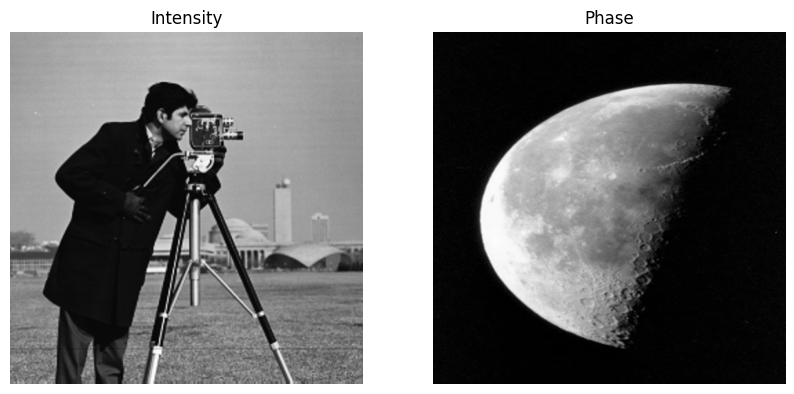

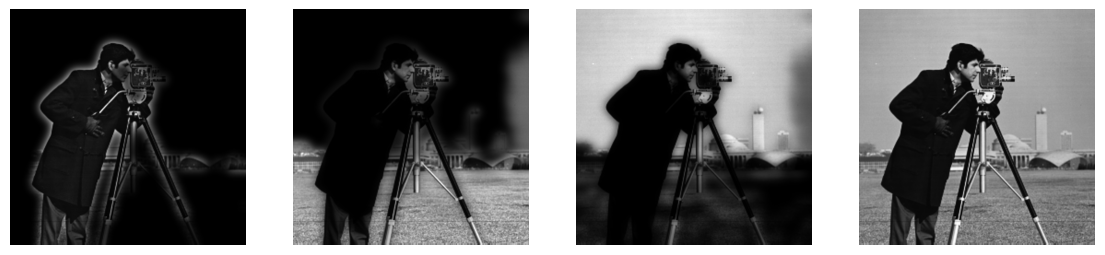

In [6]:
if not load_neuron:
    overlap = 0.75
    N = 1<<9
    img1 = np.array(Image.open(resource_path.joinpath("cameraman.png")).convert("L").resize((N, N)))
    img2 = np.array(Image.open(resource_path.joinpath("moon.png")).convert("L").resize((N, N)))

    lvls = [[0, 60], [50, 150], [140, 255]]
    mask = np.array([gaussian_filter(((img1 > lvl[0]) & (img1 < lvl[1])).astype(float), sigma=10) for lvl in lvls])
    mask *= (img1/mask.sum(axis=0, keepdims=True))
    
    sample = sqrt(img1 / img1.max()) * np.exp(2j * TAU * (img2 / img2.max()))
    
    # Display images
    fig, axs = plt.subplots(ncols=2, figsize=(10, 5))

    ax = axs[0]
    ax.imshow(img1, cmap="gray", aspect="equal")
    ax.set_title("Intensity")
    ax.axis("off")

    ax = axs[1]
    ax.imshow(img2, cmap="gray", aspect="equal")
    ax.set_title("Phase")
    ax.axis("off")

    plt.show()
    
    fig, axs = plt.subplots(ncols=4, figsize=(14, 5))
    for na, ax in enumerate(axs[:-1]):
        ax.imshow(mask[na], cmap="gray", aspect="equal")
        ax.axis("off")
        
    ax = axs[-1]
    ax.imshow(mask.sum(axis=0), cmap="gray", aspect="equal")
    ax.axis("off")
    plt.show()

## Initialisation

### Generate Sample

Create a complex transmission function using the RGBL values and extract dimension sizes.

In [ ]:
Nys, Nxs = sample.shape

nxs = np.arange(Nxs)
nys = np.arange(Nys)
dkxs = TAU / Nxs
dkys = TAU / Nys
kxs = (nxs - Nxs // 2) * dkxs
kys = (nys - Nys // 2) * dkys


### Generate Probe

#### Probe dimension size

In [ ]:
Nm = 1 << 6 # Number of pixels in measured data (square)
nm = np.arange(Nm)
dkm = TAU / Nm
km = (nm - Nm // 2) * dkm
prop = lambda E, L: f2s(s2f(E) * np.exp(-1j * (col(km)**2 + row(km)**2)*L))


#### Complex Probe Field

In [ ]:
# Initial probe
r2 = col(nm-Nm//2+1)**2 + row(nm-Nm//2+1)**2
r = sqrt(r2)
probe = gauss1d(r, 0, Nm*.8, 1)

# Mask probe
probe *= gauss1d(r, 0, Nm*.9, 10)

# Propagate probe
probe = prop(probe, 10)

# Filter probe
probe *= gauss1d(r, 0, Nm*.75, 5)

plt.imshow(abs2(probe))
plt.grid()
plt.title("Probe")
plt.show()

#### Probe Positions

In [ ]:
offset = 5
max_offset = 3 * offset + 1
Nxp = int(((Nxs - 2 * max_offset) / Nm - overlap) / (1 - overlap)) + 1
Nyp = int(((Nys - 2 * max_offset) / Nm - overlap) / (1 - overlap)) + 1
Np = Nxp * Nyp
res_m = (1 - overlap) * Nm
xp, yp = map(
    lambda x: x.flatten(),
    np.meshgrid(
        np.linspace(max_offset + Nm / 2, Nxs - max_offset - Nm / 2, Nxp),
        np.linspace(max_offset + Nm / 2, Nys - max_offset - Nm / 2, Nyp),
    ),
)
xp += np.random.normal(0, offset, xp.shape)
yp += np.random.normal(0, offset, yp.shape)
xp[xp < max_offset] = max_offset
xp[xp > Nxs - max_offset] = Nxs - max_offset
yp[yp < max_offset] = max_offset
yp[yp > Nys - max_offset] = Nys - max_offset

# Ensure integer positions (to be fixed later)
xp = np.floor(xp)
yp = np.floor(yp)

plotgrid = lambda ax, *args, **kwargs: ax.plot(
    row(xp) + col(np.array([-1, 1, 1, -1, -1], dtype=float) * Nm / 2),
    row(yp) + col(np.array([-1, -1, 1, 1, -1], dtype=float) * Nm / 2),
    *args,
    **kwargs
)

fig, ax = plt.subplots(figsize=(Nxp, Nyp))
ax.plot(xp, yp, "+")
plotgrid(ax, "--")
ax.set_xlim(0, Nxs)
ax.set_ylim(0, Nys)
ax.set_aspect("equal")
ax.set_title("Probe Sampling")
ax.grid(ls=":")
plt.show()

### Generate Scattergrams

In [ ]:
shift_sample = lambda E, dx, dy: f2s(s2f(E) * np.exp(-1j * (col(dy * kys) + row(dx * kxs))))
shift_probe = lambda E, dx, dy: f2s(s2f(E) * np.exp(-1j * (col(dy * km) + row(dx * km))))

def indices(x0, y0):
    x0 -= (Nm//2+1)
    y0 -= (Nm//2+1)
    nx0 = int(x0)
    ny0 = int(y0)
    return (x0, y0, nx0, ny0)    

def extract_subset(sample:NDArray, x0:float, y0:float, interp:bool=False, order:int=1) -> NDArray:
    x0, y0, nx0, ny0 = indices(x0, y0)
    ret = sample[ny0:ny0+Nm, nx0:nx0+Nm]
    if interp:
        coords = np.meshgrid(nm + x0 - nx0,nm + y0 - ny0)
        ret = map_coordinates(ret, coords, order=order)
    else:
        ret = shift_probe(ret, nx0-x0, ny0-y0)
    return ret

def insert_subset(sample:NDArray, subset:NDArray, x0:float, y0:float, interp:bool=False, order:int=1) -> NDArray:
    x0, y0, nx0, ny0 = indices(x0, y0)
    if interp:
        coords = np.meshgrid(nm - x0 + nx0,nm - y0 + ny0)
        subset = map_coordinates(subset, coords, order=order)
    else:
        subset = shift_probe(subset, x0-nx0, y0-ny0)
    sample[ny0:ny0+Nm, nx0:nx0+Nm] = subset
    return sample


In [ ]:
subset = np.array([extract_subset(sample, x, y, interp=False) for x, y in zip(xp, yp)])
near_field = subset*probe
far_field = abs2(s2f(near_field))

#### Plot Probed Sample

In [ ]:
fig1, axs1 = plt.subplots(nrows=Nyp, ncols=Nxp, figsize=(Nxp, Nyp))
fig2, axs2 = plt.subplots(nrows=Nyp, ncols=Nxp, figsize=(Nxp, Nyp))
fig3, axs3 = plt.subplots(nrows=Nyp, ncols=Nxp, figsize=(Nxp, Nyp))
for axn in [axs1, axs2, axs3]:
    for ax in axn.flat:
        ax.axis("off")

for fig, title in zip([fig1, fig2, fig3], ["Subset", "Near-field", "Far-field"]):
    fig.subplots_adjust(wspace=0.05, hspace=0.05)  # Adjust spacing
    fig.suptitle(title)

for ny0 in range(Nyp):
    for nx0 in range(Nxp):
        n = np.ravel_multi_index((ny0, nx0), (Nyp, Nxp))
        ax1 = axs1[ny0, nx0]
        ax2 = axs2[ny0, nx0]
        ax3 = axs3[ny0, nx0]
        ax1.imshow(abs2(subset[n]))
        ax2.imshow(abs2(near_field[n]))
        ax3.imshow(far_field[n]**.1)
plt.show()

#### Plot Probed Area

In [ ]:
tmp1 = 0*sample
tmp2 = 0*sample

for n in range(Np):
        tmp1 = insert_subset(tmp1, subset[n], xp[n], yp[n], interp=False)
        tmp2 = insert_subset(tmp2, probe, xp[n], yp[n], interp=False)

fig, axs = plt.subplots(ncols=2, figsize=(10, 4))

ax = axs[0]
im = ax.imshow(abs(tmp1))
ax.plot(xp, yp, "ko")
plotgrid(ax, "k:", lw=1)

ax = axs[1]
im = ax.imshow(abs(tmp2))
ax.plot(xp, yp, "ko")
plotgrid(ax, "k:", lw=1)

plt.show()

## Reconstruction

### Initial Guess

In [ ]:
probe_recon = gauss1d(r, 0, Nm*.6, 2) + 0j# * exp(.001j*np.random.normal(np.zeros((Nm, Nm)), PI))
# probe_recon = probe
sample_recon = np.random.normal(np.ones((Nys, Nxs)), 1) + 1j*np.random.normal(np.zeros((Nys, Nxs)), 1)
sample_recon = sample_recon / abs(sample_recon).max()
# recon = np.ones((Nys, Nxs)) + 0j
ff = sqrt(far_field)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

ax = axs[0]
im = ax.imshow(abs2(sample_recon), aspect="auto")
fig.colorbar(im)
ax.set_title("Initial Sample")

ax = axs[1]
im = ax.imshow(abs2(probe_recon), aspect="auto")
fig.colorbar(im)
ax.set_title("Initial Probe")

plt.show()

In [ ]:
alpha = 1
beta = .1
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 7))
fig.subplots_adjust(wspace=0.05, hspace=0.1)  # Adjust spacing

getind = lambda x: ((abs(xp - Nxs / 2) < x) & (abs(yp - Nys / 2) < x)).nonzero()[0]
w = 0.1*Nm
while getind(w).size<3:
    w *= 1.1
ind = getind(w)

for iter in range(200):
    # alpha = min(1.1*alpha, 1)
    beta = min(1.05*beta, 1)
    if len(ind)<Np:
        w *= 1.05
        ind = getind(w)
        np.random.shuffle(ind)
    elif (iter%10)==0:
        P = abs2(probe_recon)
        S = P.sum()
        dx0p = Nm/2-(nm*(P.sum(axis=0))).sum()/S
        dy0p = Nm/2-(nm*(P.sum(axis=1))).sum()/S
        probe_recon = shift_probe(probe_recon, dx0p, dy0p)
        sample_recon = shift_sample(sample_recon, dx0p, dy0p)
        ind = np.arange(Np)
    else:
        np.random.shuffle(ind)
    for n in ind:

        O = extract_subset(sample_recon, xp[n], yp[n], interp=False)
        P = probe_recon
        psi = O * probe_recon
        
        psi1 = s2f(psi)
        psi1 *= ff[n]/(1e-12+abs(psi1))
        psi1 = f2s(psi1)
        
        delta = psi1 - psi
        dO = alpha * delta * P.conj()/abs2(P).max()
        dP = beta * delta * O.conj()/abs2(O).max()
        
        probe_recon += dP
        sample_recon = insert_subset(sample_recon, O + dO, xp[n], yp[n], interp=False)
    
    clear_output(wait=True)
    
    ax = axs[0,0]
    im = ax.imshow(abs2(sample), aspect="equal")
    ax.set_title("Original Sample")
    ax.axis("off")

    ax = axs[1,0]
    im = ax.imshow(abs2(probe), aspect="equal")
    ax.set_title("Original Probe")
    ax.axis("off")
    
    ax = axs[0,1]
    im = ax.imshow(abs2(sample_recon), aspect="equal")
    ax.set_title("Reconstructed Sample")
    ax.axis("off")

    ax = axs[1,1]
    im = ax.imshow(abs2(probe_recon), aspect="equal")
    ax.set_title("Reconstructed Probe")
    ax.axis("off")
        
    fig.suptitle(f"Iteration: {iter}, Beta: {beta:.2f}, N: {ind.size}/{Np}")    
    display(fig)


In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(14, 8))

ax = axs[0,0]
im = ax.imshow(abs2(sample), aspect="auto")
ax.set_title("Original Sample")
fig.colorbar(im)

ax = axs[1,0]
im = ax.imshow(abs2(probe), aspect="auto")
ax.set_title("Original Probe")
fig.colorbar(im)

ax = axs[0,1]
im = ax.imshow(abs2(sample_recon), aspect="auto")
ax.set_title("Reconstructed Sample")
fig.colorbar(im)

ax = axs[1,1]
im = ax.imshow(abs2(probe_recon), aspect="auto")
ax.set_title("Reconstructed Probe")
fig.colorbar(im)
    

plt.show()